In [418]:
import optuna
from typing import Callable
import pandas as pd
import math
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.ERROR)


SAVE_FILENAME = 'results.csv'

In [419]:
def pol(odd_coefs):
    def f(x: float):
        ans = 0
        summer = x
        x_sqr = x*x
        for coef in odd_coefs:
            ans += coef * summer
            summer *= x_sqr
        return ans
    return f

In [420]:
def repeat_func(f: Callable, times: int):
    def ans(x):
        result = x
        for _ in range(times):
            result = f(result)
        return result
    return ans

In [ ]:
def sign_l2_loss(f: Callable, interval=[0,1], h=1e-5):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right    
    n_steps = int((right - left) / h)
    assert n_steps != 0, "Слишком маленький интервал по сравнению с шагом"
    try:
        x = left
        ans = h * f(x) ** 2
        for _ in range(1, n_steps):
            x += h
            ans += h * (f(x)-1) ** 2
        return ans ** 0.5
    except OverflowError:
        return 100

In [ ]:
def sign_max_loss(f: Callable, interval=[0,1], h=1e-5):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right    
    n_steps = int((right - left) / h)
    assert n_steps != 0, "Слишком маленький интервал по сравнению с шагом"
    try:
        x = left
        ans = abs(f(x))
        for i in range(1, n_steps):
            x += h
            ans = max(ans, abs(f(x)-1))
        return ans
    except OverflowError:
        return 100

In [423]:
def NewtonS(odd_coefs: list, n: int):
    f = pol(odd_coefs)
    f = repeat_func(f, n)
    return f


In [424]:
def abstruct_objective(coef_len: int, max_x: float, n: int, metric='l2'):
    def objective(trial: optuna.Trial):
        odd_coefs = []
        for i in range(coef_len):
            odd_coefs.append(
                trial.suggest_float(f"a{i}", -10, 10)
            )
        f = NewtonS(odd_coefs, n)
        loss = float('nan')
        if metric == 'l2':
            loss = sign_l2_loss(f, [0, max_x], max_x / 1e4)
        elif metric == 'max':
            loss = sign_max_loss(f, [0, max_x], max_x / 1e4)
        if math.isnan(loss):
            return 100
        return loss
    return objective

In [425]:
def experiment(coef_len: int, max_x: float, n: int, metric='l2'):
    sampler = optuna.samplers.TPESampler()
    study = optuna.create_study(
        sampler=sampler,
        direction='minimize'
    )
    study.optimize(abstruct_objective(coef_len, max_x, n, metric=metric), n_jobs=-1, n_trials=1000, show_progress_bar=True)
    return (coef_len, max_x, n, study.best_value, study.best_params)


In [426]:
results = []
for coef_len in [3, 5, 7]:
    odd_coef_len = coef_len // 2 + 1
    for max_x in [1, 5, 10, 20]:
        for n in [5, 8]:
            results.append(
                experiment(odd_coef_len, max_x, n, 'l2')
            )

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [427]:
def get_df(results: list[tuple[int, int, int, float, dict[str, float]]]):
    coef_counts, max_xs, NSs, losses, ds = zip(*results)
    d_a1 = [d.get('a0', 0) for d in ds]
    d_a3 = [d.get('a1', 0) for d in ds]
    d_a5 = [d.get('a2', 0) for d in ds]
    d_a7 = [d.get('a3', 0) for d in ds]
    df = pd.DataFrame({
        "loss": losses,
        "coef_count": coef_counts,
        "max_x": max_xs,
        "NS_n": NSs,
        "a1": d_a1,
        "a3": d_a3,
        "a5": d_a5,
        "a7": d_a7,
    })
    return df

In [428]:
df = get_df(results)
df

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,0.119116,2,1,5,1.951882,-0.963492,0.000000,0.000000
1,0.049264,2,1,8,1.878266,-0.866956,0.000000,0.000000
2,4.645075,2,5,5,1.635045,-0.063888,0.000000,0.000000
3,5.304281,2,5,8,-1.929409,0.101094,0.000000,0.000000
4,100.000000,2,10,5,4.451080,-1.463346,0.000000,0.000000
5,100.000000,2,10,8,1.114105,-2.587993,0.000000,0.000000
6,100.000000,2,20,5,7.046380,4.570139,0.000000,0.000000
7,100.000000,2,20,8,-2.695371,4.070191,0.000000,0.000000
8,0.286976,3,1,5,3.398588,-6.695414,4.152940,0.000000
9,0.016764,3,1,8,-2.456884,2.649393,-1.188216,0.000000


In [429]:
df.to_csv(path_or_buf=SAVE_FILENAME, index=False)

In [430]:
def plots(df: pd.DataFrame, max_x = 1, alpha=0.5):
    max_x_per_cent = 100 * max_x
    for n_row, row in df[df['max_x'] == max_x].iterrows():
        f = NewtonS([row[f'a{i}']for i in range(1, 8, 2)], int(row['NS_n']))
        x_es = [i/100 for i in range(max_x_per_cent)]
        y_es = [f(i/100) for i in range(max_x_per_cent)]
        if max(*y_es) > 10 or min(*y_es) < -10:
            continue
        plt.plot(x_es, y_es, label=n_row, alpha=alpha)
    plt.legend()
    plt.show()

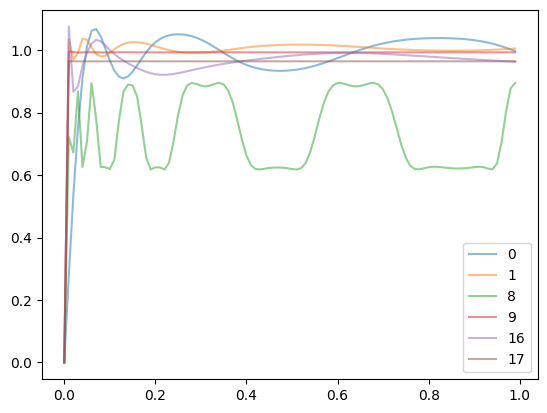

In [431]:
plots(df)

In [432]:
def plots_minimum(df: pd.DataFrame, n_points: int = 100):
    min_loss = df[df['loss'] != 0.0]['loss'].min()
    row: pd.DataFrame = df[df['loss'] == min_loss]
    max_x = row['max_x'].iloc[0]
    f = NewtonS([row[f'a{i}'].iloc[0] for i in range(1, 8, 2)], int(row['NS_n'].iloc[0]))
    x_es = [i/n_points for i in range(max_x * n_points)]
    y_es = [f(i/n_points) for i in range(max_x * n_points)]
    plt.plot(x_es, y_es)
    plt.show()
    return f

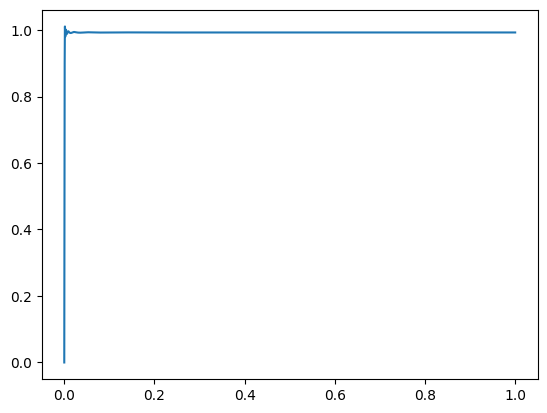

In [433]:
f = plots_minimum(df, 10000)

In [434]:
f(0), f(1e-4), f(1e-5), f(1e-6), f(1e-7), f(1e-8), f(1e-9),

(0.0,
 0.13226315899227012,
 0.013275783265665505,
 0.001327627929209012,
 0.00013276284252489897,
 1.3276284302093909e-05,
 1.3276284302589947e-06)

C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer


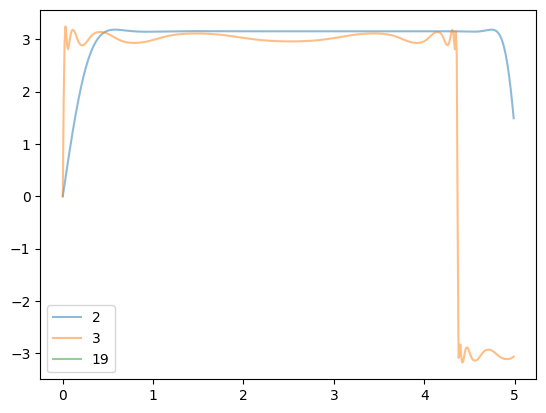

In [435]:
plots(df, max_x = 5)

C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer


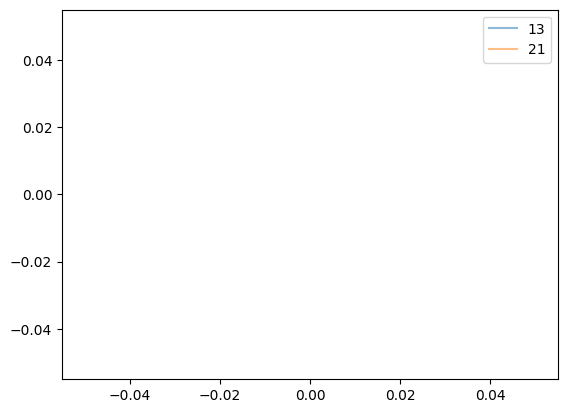

In [436]:
plots(df, max_x = 10)

C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x


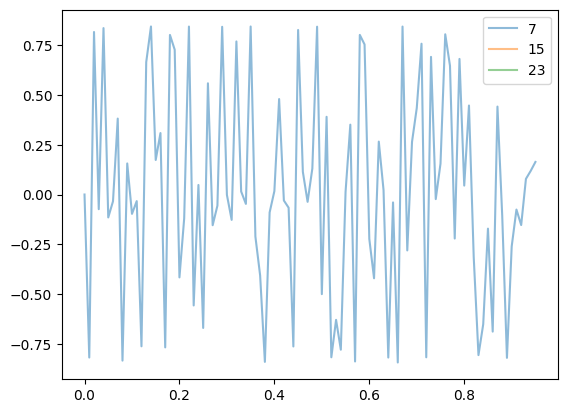

In [437]:
plots(df, max_x = 20)

In [438]:
results_l2 = []
for coef_len in [3, 5, 7]:
    odd_coef_len = coef_len // 2 + 1
    for max_x in [1, 5, 10, 20]:
        for n in [5, 8]:
            results_l2.append(
                experiment(odd_coef_len, max_x, n, 'max')
            )

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [439]:
df_2 = get_df(results_l2)
df_2

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,9.882706e-01,2,1,5,2.593320,-0.784668,0.000000,0.000000
1,8.387037e-01,2,1,8,2.518545,-1.858919,0.000000,0.000000
2,9.999845e-01,2,5,5,0.498947,-0.008898,0.000000,0.000000
3,9.999118e-01,2,5,8,-0.805021,0.022702,0.000000,0.000000
4,2.711947e+00,2,10,5,1.074818,-0.007607,0.000000,0.000000
5,4.989921e+165,2,10,8,-1.764289,0.027930,0.000000,0.000000
6,1.964169e+01,2,20,5,1.618520,-0.001474,0.000000,0.000000
7,inf,2,20,8,-4.118435,2.785468,0.000000,0.000000
8,8.822029e-01,3,1,5,4.114544,-5.143178,1.653439,0.000000
9,1.878935e-01,3,1,8,-3.140329,4.224922,-1.896752,0.000000


C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer


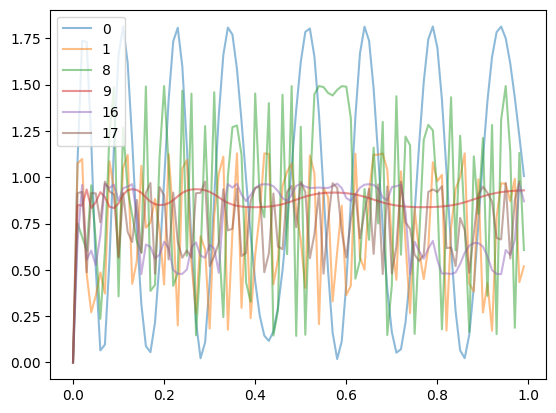

In [440]:
plots(df_2)

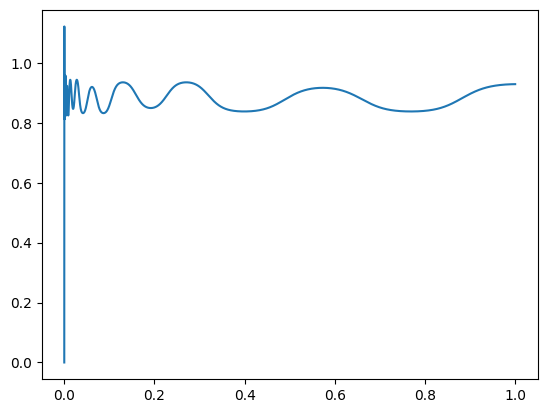

In [441]:
f = plots_minimum(df_2, 100000)

In [442]:
f(0), f(1e-1), f(1e-2), f(1e-3), f(1e-4), f(1e-5), f(1e-6), f(1e-7), f(1e-8), f(1e-9), f(1e-10), f(1e-11),  f(1e-12),

(0.0,
 0.8581186751595637,
 0.8495017063626313,
 0.8399291551441883,
 0.8265090396944488,
 0.09445205099785263,
 0.009457912015169764,
 0.0009458039178990023,
 9.458040450637697e-05,
 9.458040463354179e-06,
 9.458040463481342e-07,
 9.458040463482611e-08,
 9.458040463482625e-09)

In [443]:
f(1e-100)

9.458040463482626e-97

In [444]:
f(0.5)

0.8873047066034535